# 07 · Smaller and faster for a Jetson: `sensitivity` and `optimize`

## Overview

Your model works on a PC with a big GPU. Now it must run on a small device, for example an NVIDIA
Jetson inside a robot. A smaller model file loads faster and uses less memory, and it can run
faster. But a smaller model stores its numbers less precisely, and it can lose accuracy. This
notebook shows how VisionServe finds a good balance, and how you check it on the device.

**What you will learn**

- Why edge devices need smaller and faster models, and what a Jetson Orin and a Jetson Thor are.
- The number formats FP32, FP16, INT8, INT4 and *mixed*, with a tiny example of rounding.
- `visionserve sensitivity`: which layers of the model do not like INT8, with the chart.
- `visionserve optimize --target jetson-orin`: build each smaller variant, measure it, and pick
  one. How to read size, error, mAP drop and latency.
- `--install` a variant and time it with `visionserve bench`.
- The last step, on the device: copy the model folder and run `bench` **there**.

**Time:** about 30 minutes to read. The commands run for about 8 to 20 minutes on a PC with an
NVIDIA GPU: `sensitivity` 3 to 10 minutes (it runs on the CPU), `optimize` 5 to 9 minutes, `bench`
about 1 minute. Here (a shared 48-core PC with RTX A6000 GPUs) the whole notebook took 8 minutes
when the machine was quiet and 18 minutes when other jobs used it.
Without a GPU, `optimize` also measures on the CPU and takes longer (about 10 to 20 minutes, it
depends on your CPU).

**Before you start**

- A running VisionServe server and the `visionserve` program (notebook 00 and the README).
- The model `rf-detr-nano` (the notebook downloads it if it is missing). Your own `my-detector`
  from notebook 04 works the same way: change `MODEL` in section 1.
- The **converter** (Python code that builds the smaller files). Pick one:
  - **Docker**: `visionserve sensitivity ...` starts the converter image for you
    (`--gpu` picks the CUDA image).
  - **The Python package**: `pip install "visionserve[convert]"` in the Python of this notebook.
    The commands then get `--python <this Python>` (or set `VISIONSERVE_CONVERT_PYTHON`).
- Optional, for accuracy: COCO val2017 (a free public data set of labelled photos). Set
  `COCO_DIR` to the folder that holds `annotations/instances_val2017.json` and `val2017/`.
  Without it, `optimize` still runs, but it cannot measure accuracy.
- Optional: an NVIDIA GPU. Nothing in this notebook runs on a Jetson.

As in notebook 04, we made the outputs with a practice registry; it is shown as `…/models`.

**Steps**

1. Set up
2. Why smaller and faster? Edge devices and the Jetson
3. Number formats: FP32, FP16, INT8, INT4, mixed
4. Which layers are sensitive? `visionserve sensitivity`
5. Labelled photos, to measure accuracy
6. Pick a variant: `visionserve optimize`
7. Time it: `visionserve bench`
8. On the device (not run here)
9. Clean up

## 1. Set up

We connect to the server, make sure the model is installed, make a scratch folder `work-07`, and
choose where the converter runs (like in notebook 04).

In [1]:
import importlib.util
import json
import os
import re
import shutil
import subprocess
import sys
import time
from pathlib import Path

import handson as ho

client = ho.connect()
MODEL = "rf-detr-nano"                   # or "my-detector" from notebook 04
ho.ensure_model(client, MODEL)

MODELS = Path(os.environ.get("VISIONSERVE_MODELS") or Path.home() / ".visionserve" / "models")
WORK = Path("work-07")
WORK.mkdir(exist_ok=True)
PHOTOS = ho.photo("cat").parent          # hands-on/images: 8 sample photos
GPU = shutil.which("nvidia-smi") is not None

TUNE_WITH = os.environ.get("VS_CONVERT_WITH") or (
    "python" if all(importlib.util.find_spec(m) for m in ("onnx", "onnxruntime", "visionserve.convert")) else "docker")
print("the converter runs with:", TUNE_WITH, "| NVIDIA GPU on this machine:", GPU)


def tune(tool, *args):
    """Run `visionserve sensitivity|optimize`. With the Python package, add --python <this Python>."""
    extra = ["--python", sys.executable] if TUNE_WITH == "python" else []
    start = time.time()
    out = ho.run_cli(tool, *args, *extra, "--models", MODELS)
    print(f"[took {(time.time() - start) / 60:.1f} min]")
    return out

Connected to VisionServe at http://127.0.0.1:11790: {'status': 'ok'}
Model 'rf-detr-nano' is installed (state: available).
the converter runs with: python | NVIDIA GPU on this machine: True


**What you see**

One line for the server, one for the model, and one that says where the converter runs and
whether this machine has an NVIDIA GPU.

<details><summary><b>In detail</b></summary>

- `sensitivity` and `optimize` are commands of the Go program. They start the converter for the
  heavy work: the Docker image by default, or a local Python with `--python PY` (or the
  environment variable `VISIONSERVE_CONVERT_PYTHON`). The local Python needs the package
  `visionserve[convert]`, and `VISIONSERVE_BIN` if the Go program is not on your PATH.
- With Docker, `--gpu` uses the CUDA converter image (`...-gpu`, about 10 GB) and gives it the GPU.
- More: [Clients and the converter](https://mtbui2010.github.io/vision_serve/architecture/clients/).

</details>

## 2. Why smaller and faster? Edge devices and the Jetson

An **edge device** is a computer that runs *where the data is*: in a robot, a camera or a machine,
not in a data centre. It has little memory and little power, and often a hard time limit (a robot
arm must decide in, say, 50 ms).

**NVIDIA Jetson** is a family of such small computers with an NVIDIA GPU on the same chip:

- **Jetson Orin** (AGX Orin, Orin NX, Orin Nano): the current common one. Its GPU is the same
  generation as many PC GPUs (Ampere). It has fast hardware for FP16 and INT8 numbers.
- **Jetson Thor**: the newest one (Blackwell GPU). It adds hardware for FP8 and FP4 numbers.

On a Jetson, the GPU and the CPU **share** one memory. A big model file takes memory from
everything else. A smaller file also copies and loads faster.

How big is our model now?

rf-detr-base.onnx: 107.8 MB
6 objects found in 'dogs', 878 ms on gpu:0


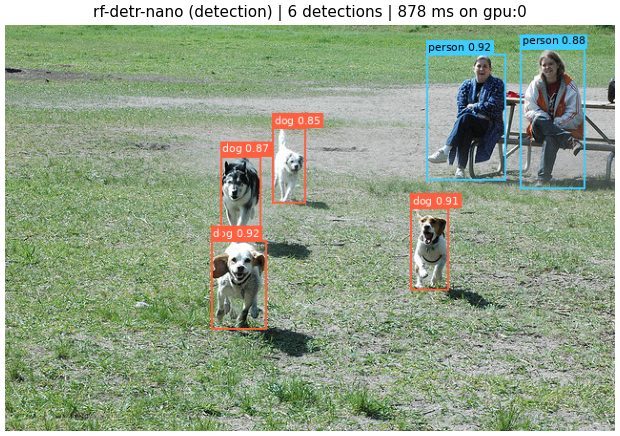

In [2]:
folder = MODELS / MODEL
onnx_files = sorted(folder.glob("*.onnx"))
for f in onnx_files:
    print(f"{f.name}: {f.stat().st_size / 1e6:.1f} MB")
res = client.predict(MODEL, ho.photo("dogs"))
print(f"{len(res.detections)} objects found in 'dogs', {res.duration_ms:.0f} ms on {res.device}")
ho.show(ho.photo("dogs"), res)

**What you see**

- The model file is about 108 MB. It holds about 27 million weights, each stored as a 4-byte
  number (FP32).
- One prediction on this PC, with the time and the device (`gpu:0` = the first GPU, or `cpu`).
  The first request also loads the model, so it is slower than the next ones.
- The photo with the boxes.

<details><summary><b>In detail</b></summary>

- The local file is called `rf-detr-base.onnx` for a historical reason; its content is the Nano
  model (the manifest explains it).
- Orin: Ampere GPU (sm_87), FP16 and INT8 tensor cores, no FP8. Thor: Blackwell GPU (sm_110), with
  FP8 and FP4 tensor cores. A *tensor core* is a part of the GPU made for fast matrix math in
  small number formats.
- More: [Jetson details](https://mtbui2010.github.io/vision_serve/guides/edge/).

</details>

## 3. Number formats: FP32, FP16, INT8, INT4, mixed

A model is mostly a long list of numbers (the *weights*). The format says how many **bits** (0 or
1 digits) store each number:

| Format | Bits | Bytes | What it stores | Model file (vs FP32) |
|---|---|---|---|---|
| **FP32** | 32 | 4 | a *floating-point* number: about 7 correct digits, very large and very small values | 1× (the normal case) |
| **FP16** | 16 | 2 | a floating-point number: about 3 correct digits, at most 65504 | about ½ |
| **INT8** | 8 | 1 | a whole number from −128 to 127, times one shared *scale* per layer or row | about ¼ |
| **INT4** | 4 | ½ | a whole number from −8 to 7, times a scale per small block | about ⅛ (weights only) |
| **mixed** | — | — | each layer gets its own format: the sensitive layers keep more bits | between |

*Floating-point* means the number has a "moving decimal point", like 1.234 × 10⁻⁵. Reducing the
format is called **quantization**. Let us see the rounding with real numbers.

In [3]:
import numpy as np

# 1) Floating point: the same values stored as FP32 and FP16
values = [0.1234567, 3.14159265, 0.0001234, 70000.0]
rows = []
for v in values:
    with np.errstate(over="ignore"):          # 70000 is too large for FP16: no warning, please
        f32, f16 = float(np.float32(v)), float(np.float16(v))
    rows.append([v, f"{f32:.7g}", f"{f16:.7g}", f"{abs(f16 - v):.2g}"])
ho.table(rows, ["value", "as FP32", "as FP16", "FP16 error"])

# 2) INT8 and INT4: five weights of one layer share one scale
w = np.array([0.82, -0.31, 0.05, 0.0012, -0.66])
for name, top in [("INT8", 127), ("INT4", 7)]:
    scale = np.abs(w).max() / top               # the largest weight becomes +-top
    q = np.clip(np.round(w / scale), -top - 1, top).astype(int)
    back = q * scale                            # what the model computes with
    print(f"{name}: scale {scale:.5f}, stored {q.tolist()}, back {np.round(back, 4).tolist()}, "
          f"largest error {np.abs(back - w).max():.4f}")

value,as FP32,as FP16,FP16 error
0.123,0.1234567,0.1234741,1.7e-05
3.14,3.141593,3.140625,0.00097
0.000123,0.0001234,0.0001233816,1.8e-08
70000,70000,inf,inf


INT8: scale 0.00646, stored [127, -48, 8, 0, -102], back [0.82, -0.3099, 0.0517, 0.0, -0.6586], largest error 0.0017
INT4: scale 0.11714, stored [7, -3, 0, 0, -6], back [0.82, -0.3514, 0.0, 0.0, -0.7029], largest error 0.0500


**What you see**

- **FP16** keeps about 3 to 4 correct digits: `0.1234567` becomes `0.1234741`. The error is tiny
  for most weights. But `70000` becomes `inf` (infinity): FP16 cannot store values above 65504.
  That is why some layers (with large values) are better left in FP32.
- **INT8** stores whole numbers and one *scale* (here 0.82 / 127). `0.82` becomes `127`, `0.05`
  becomes `8`. When you multiply back, each weight moves by at most half a step (≈ 0.003). A tiny
  weight like `0.0012` becomes `0`: it is lost.
- **INT4** has only 16 steps, so the steps are big (≈ 0.12): `0.05` and `0.0012` both become `0`,
  and the error is up to about 0.06. Fine for some layers, bad for others.

One rounding error is small. A model does millions of multiplications, and in some layers the
errors grow. **Which layers?** That is what `sensitivity` measures.

<details><summary><b>In detail</b></summary>

- INT8 here is *static, symmetric* quantization: the scale of the weights comes from the weights;
  the scale of the *activations* (the numbers flowing between layers while the model runs) is
  measured on **calibration photos**. That is why `sensitivity` and `optimize` need `--images`:
  photos like the ones the model will see.
- In the ONNX file, INT8 is written as `QuantizeLinear` / `DequantizeLinear` pairs around each
  layer (the *QDQ* form). INT4 is weight-only (`MatMulNBits`): the activations stay in float.
- FP8 and FP4 (Thor) can only be *simulated* (for accuracy), not built: ONNX Runtime cannot run
  them.
- More: [Reduced precision](https://mtbui2010.github.io/vision_serve/guides/precision/).

</details>

## 4. Which layers are sensitive? `visionserve sensitivity`

The model has about a hundred big layers that do matrix multiplication (`MatMul`, `Gemm`) or
convolution (`Conv`). `sensitivity` takes **one layer at a time**, reduces only that layer to INT8,
runs the model on your photos, and measures how much the answer changes. A layer whose answer
changes more than 0.05 is called **sensitive**.

We use the 8 sample photos and measure two formats, INT8 and FP16 (`optimize` needs both to build
its *mixed* variant in section 6). To keep the time short (3 to 10 minutes), each layer is tested on 4 of
the photos (`--sens-images 4`; the default is 8, which takes twice as long). It runs on the CPU by
design: it creates one model session per layer and format, and a GPU session is slower to create
than it saves for a few photos.

In [4]:
out = tune("sensitivity", MODEL, "--images", PHOTOS, "--formats", "int8,fp16", "--sens-images", "4",
           "--save", WORK / "sens.json", "--report", WORK / "sens.html")

$ visionserve sensitivity rf-detr-nano --images images --formats int8,fp16 --sens-images 4 --save work-07/sens.json --report work-07/sens.html --python ~/miniconda3/envs/label/bin/python3 --models …/models
models: …/models
$ ~/miniconda3/envs/label/bin/python3 -m visionserve.convert sensitivity rf-detr-nano --images images --formats int8,fp16 --sens-images 4 --save work-07/sens.json --report work-07/sens.html --models …/models
edge: measuring int8, fp16 sensitivity of every MatMul/Gemm/Conv on 4 image(s), CPU (ONNX Runtime CPU EP) ...
  sensitivity 1/229 (int8)
  sensitivity 23/229 (int8)
  sensitivity 46/229 (int8)
  sensitivity 69/229 (int8)
  sensitivity 92/229 (int8)
  sensitivity 115/229 (fp16)
  sensitivity 138/229 (fp16)
  sensitivity 161/229 (fp16)
  sensitivity 184/229 (fp16)
  sensitivity 207/229 (fp16)
  sensitivity 229/229 (fp16)
edge: per-layer scores written to work-07/sens.json
report: work-07/sens.html
WARN: 64 of 114 layers are sensitive to INT8; the worst is …/encoder


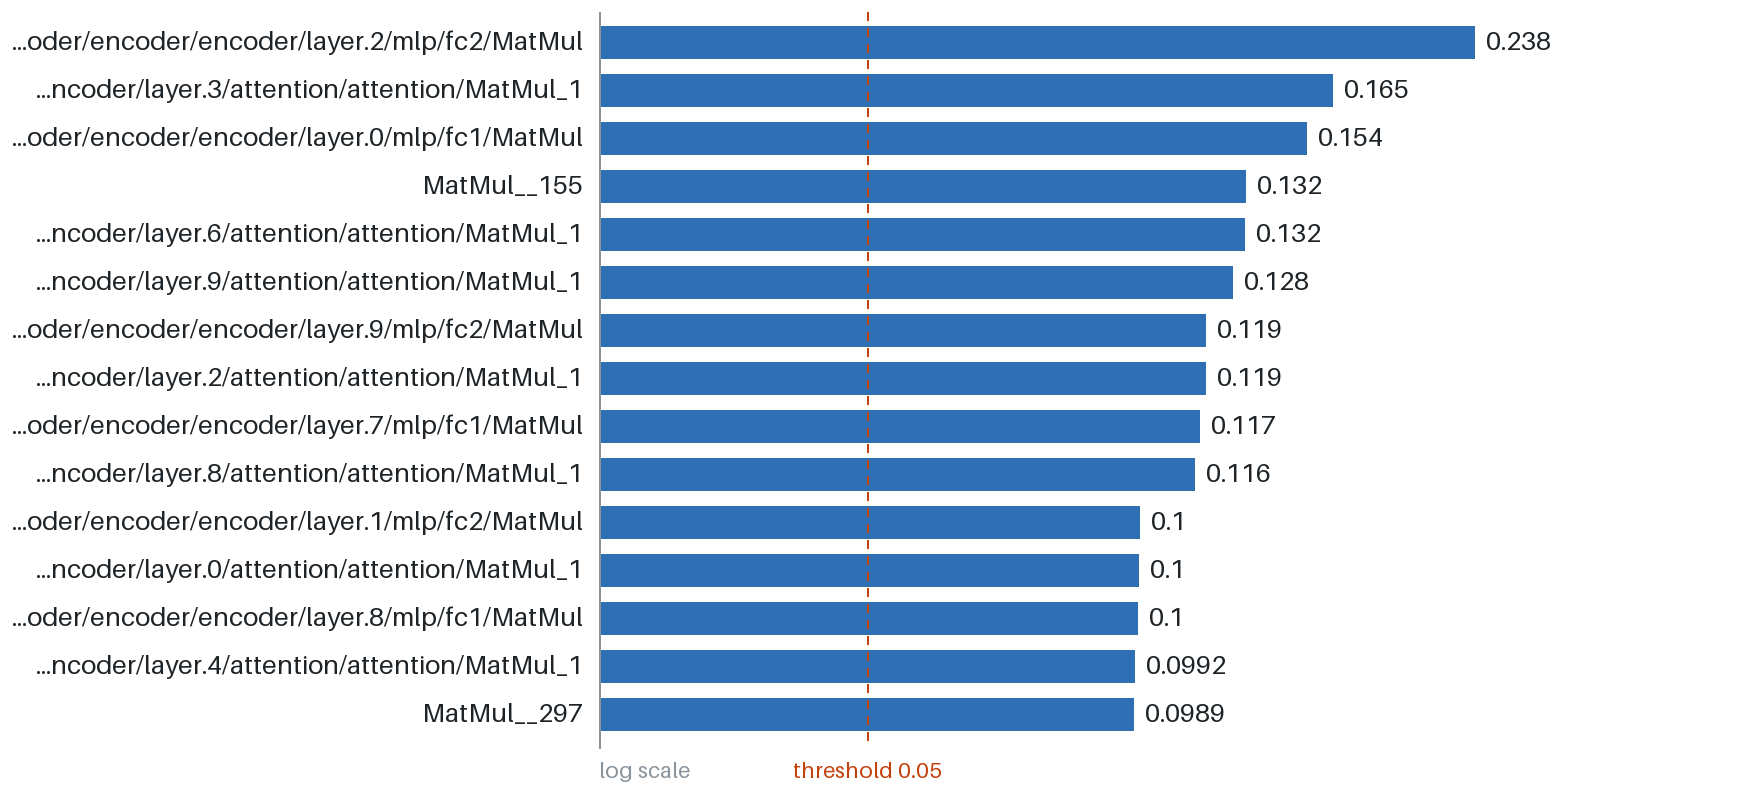

In [5]:
ho.show_html_report(WORK / "sens.html", height=650)

**What you see**

- The progress lines `sensitivity 1/229 ...`: 115 layers, two formats each.
- The verdict first: `WARN: 64 of 114 layers are sensitive to INT8; the worst is
  .../layer.2/mlp/fc2/MatMul (MatMul, error 0.238) — keep it in FP32`. `WARN` is normal for a
  *transformer* model like RF-DETR (a model built from *attention* blocks, where each part of the
  photo looks at all other parts).
- The summary: 115 layers measured. **INT8**: 64 of 114 sensitive, mean error 0.057 (one layer
  cannot take INT8 at all and stays in float). **FP16**: 0 of 115 sensitive, mean error 0.0001:
  FP16 is harmless for every layer. Then the worst layer, the photos and the time.
- **Most sensitive layers**: the 15 worst. The names are long; the end says what the layer is:
  - `mlp/fc1`, `mlp/fc2`: the two layers of the small network (*MLP*) inside each transformer block;
  - `attention/MatMul_1`: the attention step that mixes the parts of the photo.
- Columns: `err INT8` and `err FP16` are the change of the answer (0 = same boxes, 1 = nothing in
  common); `!` marks a sensitive layer. `w-SQNR dB` says how well the weights alone survive INT8 (higher is
  safer). `outlier` is the largest activation divided by a typical large one: a big ratio means a
  few huge values take most of the INT8 range, and all the other values get few steps.
- The HTML report shows the same as a bar chart: one bar per layer, sorted, with the 0.05 line.

<details><summary><b>In detail</b></summary>

- The number of sensitive layers depends on the photos and on how many are used per layer. With
  our 8 photos and 8 per layer it was 44 of 114 (INT8 only, 4.4 minutes); with 8 other COCO photos,
  9 of 114. A layer's score is a **hint**: the errors of many layers do not simply add up. Only
  accuracy on labelled photos decides (section 6).
- `--formats int8` alone takes half the time, but then `optimize --sensitivity` cannot build its
  *mixed* variant (it says: "the sensitivity scores do not cover fp16"). `--formats int8,fp8,fp4`
  simulates the Thor formats.
- `--sens-images N` sets the photos per layer (default 8; the time grows with it). `--save
  sens.json` keeps the scores, so `optimize --sensitivity sens.json` does not measure them again.
- How it works: [Reduced precision, Sensitivity](https://mtbui2010.github.io/vision_serve/guides/precision/#sensitivity) and
  [Jetson details, section 2](https://mtbui2010.github.io/vision_serve/guides/edge/#2-sensitivity-which-layers-break-at-int8).

</details>

## 5. Labelled photos, to measure accuracy

"The answer changed a little" is not the same as "the model got worse". To know, we need photos
where people marked every object (*labelled* photos, or *ground truth*) and a score of how well
the model finds them: **mAP**.

**mAP** (mean average precision) is the standard detection score, from 0 to 100. It is high when
the model finds the marked objects, with tight boxes and the right class, and few false boxes.

The small script `tools/make_coco_subset.py` takes 100 photos from COCO val2017 (not our 8
calibration photos) and writes their labels in the COCO format, the file `optimize --labels`
reads.

100 images, 714 objects -> work-07/coco-subset/instances.json, work-07/coco-subset/images/
 


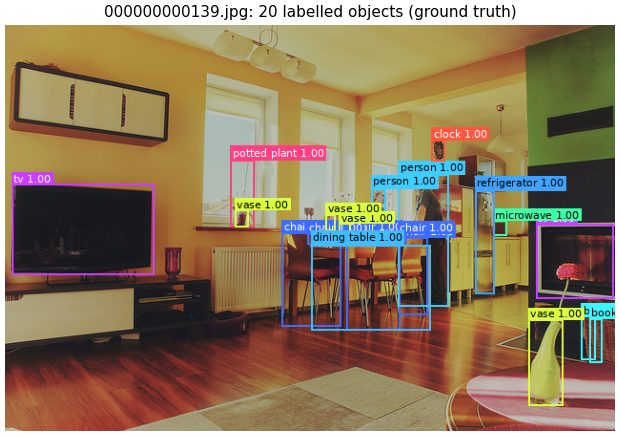

In [6]:
COCO = Path(os.environ.get("COCO_DIR", "coco"))
coco_json = COCO / "annotations" / "instances_val2017.json"
SUBSET = WORK / "coco-subset"
LABELS = None
if coco_json.is_file():
    p = subprocess.run([sys.executable, "tools/make_coco_subset.py", "--coco-json", coco_json,
                        "--coco-images", COCO / "val2017", "--out", SUBSET, "--n", "100"],
                       capture_output=True, text=True)
    print(p.stdout, p.stderr)
    LABELS = SUBSET / "instances.json"
else:
    print(f"COCO not found at {COCO}: set COCO_DIR. optimize will run without --labels "
          "(it then cannot measure accuracy).")

if LABELS:
    from visionserve import Result
    data = json.loads(LABELS.read_text())
    cats = {c["id"]: c["name"] for c in data["categories"]}
    first = data["images"][0]
    truth = [{"bbox": a["bbox"], "class": cats[a["category_id"]], "conf": 1.0}
             for a in data["annotations"] if a["image_id"] == first["id"]]
    ho.show(SUBSET / "images" / first["file_name"],
            Result.from_json({"task": "detection", "model": "labels", "detections": truth}),
            title=f"{first['file_name']}: {len(truth)} labelled objects (ground truth)")

**What you see**

- `100 images, 714 objects -> ...`: the labelled set.
- One of the photos with its **labels** drawn as boxes (every box has `conf 1.00`: a person drew
  it). This is what the model's boxes are compared with.

<details><summary><b>In detail</b></summary>

- COCO labels are `[x, y, width, height]` in pixels, the same box format as VisionServe.
- 100 photos are enough to see a big loss (several points) and to compare variants. A difference
  below about 0.5 mAP on 100 photos is noise.
- Use photos **like your deployment's**, with your own labels, for a real decision. A COCO json
  from your labelling tool works directly.
- More: [Check it behaves like training](https://mtbui2010.github.io/vision_serve/guides/check-training/) (how to make a labels file).

</details>

## 6. Pick a variant: `visionserve optimize`

`optimize` does the whole comparison for one **target** (the device you deploy to):

1. It builds every variant worth trying for that target. For `jetson-orin`: FP16, INT8 and *mixed*
   (sensitive layers stay in FP16 or FP32, the rest INT8).
2. It measures each one against FP32: **file size**, **output error** on the calibration photos,
   **mAP** on the labelled photos (through a temporary server), and **latency** on this machine.
3. It marks the **recommended** variant: inside the budget (error ≤ 0.05 and mAP drop ≤ 1 point),
   the fastest; when two are within 10 %, the smaller file.

We also pass `--sensitivity` (reuse section 4), `--gpu` (measure on this PC's GPU, the same kind of
execution provider as the Jetson's) and `--install --install-format fp16`: **install the FP16
variant**, even if it is not the recommended one, so we can time it in section 7.
This takes about 5 to 9 minutes with a GPU.

In [7]:
args = [MODEL, "--target", "jetson-orin", "--images", PHOTOS, "--sensitivity", WORK / "sens.json",
        "--install", "--install-format", "fp16", "--report", WORK / "optimize.html"]
if LABELS:
    args += ["--labels", LABELS, "--label-images", SUBSET / "images"]
if GPU:
    args += ["--gpu"]
out = tune("optimize", *args)

$ visionserve optimize rf-detr-nano --target jetson-orin --images images --sensitivity work-07/sens.json --install --install-format fp16 --report work-07/optimize.html --labels work-07/coco-subset/instances.json --label-images work-07/coco-subset/images --gpu --python ~/miniconda3/envs/label/bin/python3 --models …/models
models: …/models
$ ~/miniconda3/envs/label/bin/python3 -m visionserve.convert optimize rf-detr-nano --target jetson-orin --images images --sensitivity work-07/sens.json --install --install-format fp16 --report work-07/optimize.html --labels work-07/coco-subset/instances.json --label-images work-07/coco-subset/images --gpu --models …/models
edge: reusing 115 layer scores from work-07/sens.json
edge: fp16: 54.1 MB, output error 0.0216 (5 s)
Finding optimal threshold for each tensor using 'percentile' algorithm ...
Number of tensors : 250
Number of histogram bins : 2048
Percentile : (0.0010000000000047748,99.999)
edge: int8: 29.2 MB, output error 0.243 (23 s)
Finding opti

**What you see** (the long log first, then the result)

- `WARNING:root: Please consider pre-processing before quantization`: a message of ONNX Runtime's
  quantization tool, printed for each INT8 build. You can ignore it.
- Log lines: building each variant (`fp16`, `int8`, then the *mixed* search, which builds and
  measures several models), then `latency on this host` and `mAP on 100 labelled image(s)` for each.
- `precision: tau ... -> {'int8': 6, 'fp16': 107, 'fp32': 2} -> output error 0.04447`: the search
  for the *mixed* variant. *tau* is a limit: every layer whose own error (from section 4) is below
  tau gets INT8. Each line builds and measures a whole model, then tau moves up or down. The search
  keeps the largest tau whose model stays under the 0.05 error budget: here only 6 layers in INT8,
  107 in FP16 and 2 in FP32.
- `installed rf-detr-nano-fp16`: the FP16 file is now a model of its own, in the registry.
- The **verdict** (first line after the log), the **summary** and the **Variants** table.


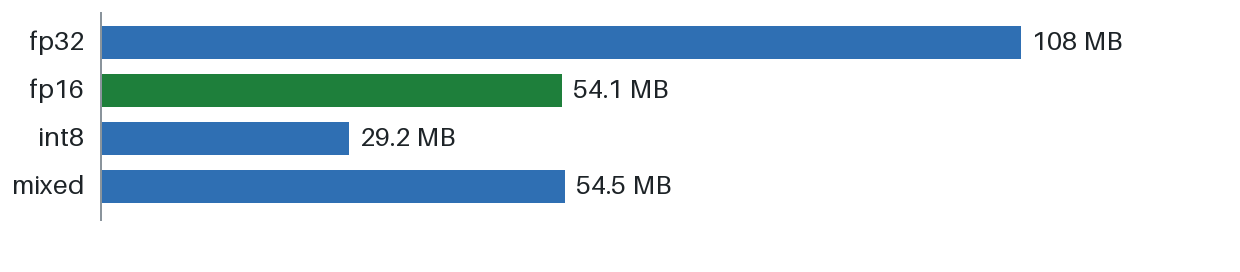
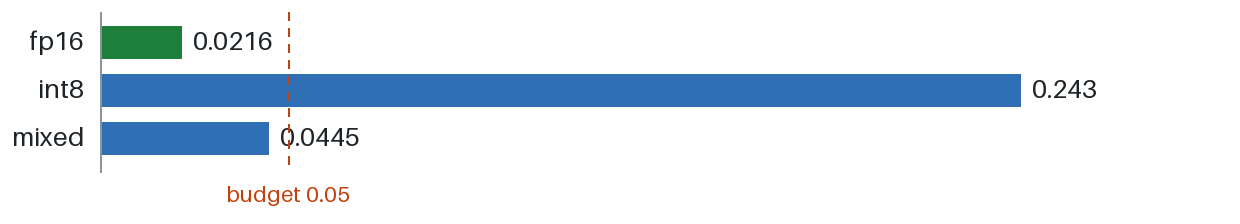
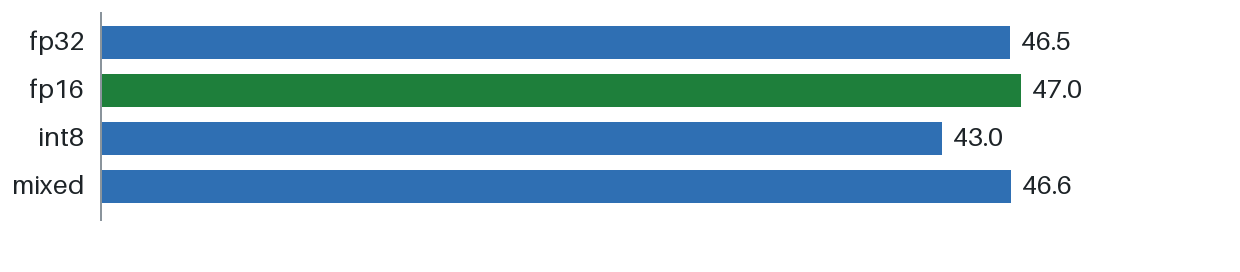

In [8]:
ho.show_html_report(WORK / "optimize.html", height=700)

**How to read the table** — one row per variant:

| Column | In plain words |
|---|---|
| **variant** | `fp32` is the original. `✓` marks the recommended row. |
| **file size** | FP16 and *mixed* halve the file; INT8 makes it about 3.7 times smaller. |
| **output error mean / max** | How far its answers are from FP32's on the 8 calibration photos: 0 = the same boxes, 1 = nothing in common. Budget: 0.05. |
| **mAP (Δ vs FP32)** | Accuracy on the 100 labelled photos, and the change against FP32 (Δ, "delta" = difference). Budget: lose at most 1 point. |
| **latency p50 / p95 (THIS host)** | Time per photo **on this PC**. *p50* = the median (half the requests are faster); *p95* = 95 % are faster. |
| **status** | `within budget`, `over budget` (with the reason), or `recommended ✓`. |

**What this run says**

- **FP32**: 107.8 MB, mAP 46.52, about 17 ms per photo here (p50).
- **INT8 everywhere is over budget**: 3.7 times smaller, but its error (0.243) is about five times
  the budget, and it loses 3.48 mAP points. Section 4 predicted it: many layers are sensitive.
- **FP16 and mixed are within budget**: half the size, and the mAP change (+0.52 and +0.04) is
  within the noise of 100 photos. *Mixed* is not smaller than FP16 here, because only 6 layers
  could take INT8 inside the budget.
- **The verdict: `WARN: recommended rf-detr-nano-fp16`**: inside the budget, FP16 was the fastest
  here (14.7 against 16.6 ms) and half the size, so it gets the `✓`. Mixed (15.6 ms) is within 10 %
  of it, and then the smaller file wins: FP16 (54.1 against 54.5 MB).
- **Why `WARN`?** `latency here was noisy`: for INT8, p95 (50.7 ms) is more than 1.5 times p50
  (24.6 ms), a sign that something else used the GPU or CPU. Then the **speed ranking may be
  noise**. Look at the numbers: 14.7 against 16.6 ms is a small difference.
- **Speed changes from run to run; accuracy does not.** We ran this notebook earlier while other
  jobs used the same GPU. The size, error and mAP columns were exactly the same. The latency was
  not: FP16 took 38.7 ms against 17.4 ms for FP32 (2.2 times **slower**), and the verdict was
  `keep FP32 for speed`. Same files, same PC, another load.

**Honest notes: what this does and does not tell you**

- **The latency column is this PC's, not the Jetson's.** A PC GPU, an Orin and a Thor differ a lot,
  and even the order of FP16 and FP32 can change. Only `bench` on the device says how fast it is
  there (section 8).
- **Smaller is not always faster.** On ONNX Runtime's CUDA support (the *CUDA execution provider*),
  FP16 can be **slower** than FP32 for rf-detr-nano: the project measured the model alone on an
  idle GPU at 16.1 ms (FP16) against 4.6 ms (FP32) per run. This is why `optimize` lets FP32
  compete instead of assuming FP16 wins.
- **INT8 is a size win on the CUDA path, not always a speed win**: ONNX Runtime's CUDA path converts
  INT8 back to float. INT8 is faster on the CPU and under TensorRT. (A shared, busy GPU
  also makes the latency numbers jump between runs.)
- **The `jetson-orin` preset ran on a PC GPU** (an RTX A6000, the same Ampere generation and the
  same execution provider), not on an Orin. **The `jetson-thor` preset is untested on hardware.**
- **Accuracy carries over to the device much better than speed**: the same ONNX file computes
  almost the same numbers there. Still check it on the device before you ship.

<details><summary><b>In detail</b></summary>

- *Execution provider* (EP): the part of ONNX Runtime that runs the model on one kind of hardware:
  `cuda` (NVIDIA GPU), `tensorrt` (NVIDIA's optimizer, opt-in), `cpu`.
- `--tensorrt` adds TensorRT rows. Under TensorRT every row was faster, and *mixed* was a good
  choice; it is shown as a separate, flagged alternative, because TensorRT measured 6.8 mAP lower on
  another model (GroundingDINO) and must be checked per model.
- Budgets: `--max-output-err 0.05` and `--max-drop 1.0` change them. `--target cpu` tries INT8,
  mixed and INT4 and measures on the CPU, where INT8 is really faster (3.8× in our run).
- `--install` without `--install-format` installs the recommended variant (nothing when it is
  FP32). The installed folder is `MODEL-FORMAT`.
- More: [Make it smaller and faster for Jetson](https://mtbui2010.github.io/vision_serve/guides/jetson/) and
  [Jetson details, section 3](https://mtbui2010.github.io/vision_serve/guides/edge/#3-optimize-the-best-variant-for-a-target).

</details>

## 7. Time it: `visionserve bench`

`bench` loads a model in the program itself (like `visionserve run`), sends a few warm-up photos,
then times many requests. We time FP32 and the FP16 variant we just installed, on this PC. First
let us look at how the installed variant records where it came from:

In [9]:
variant = f"{MODEL}-fp16"
for line in (MODELS / variant / "manifest.yaml").read_text().splitlines()[:8]:
    print(line)

# Generated by `visionserve optimize` from rf-detr-nano on 2026-10-06.
# precision: fp16 (FP16 weights and activations, float32 inputs/outputs)
# target preset: jetson-orin
# output error vs FP32: mean 0.0216, max 0.129 on 8 image(s) of images
# mAP 47.04 vs FP32 46.52 on 100 labelled image(s)
# Same preprocessing, labels and postprocessing as rf-detr-nano; only the ONNX file differs.
name: rf-detr-nano-fp16
task: detection


**What you see**

The top of the new manifest: made by `visionserve optimize` from `rf-detr-nano`, the precision
(FP16 weights and activations, float32 input and output), the target, the output error and the mAP
measured above. Everything else (photo preparation, labels, decoding) is copied from the original.
Only the ONNX file differs.

Now the timing (about 1 minute):

In [10]:
ep = "cuda" if GPU else "cpu"
summary = []
for name in [MODEL, variant]:
    out = ho.run_cli("bench", name, "--images", PHOTOS, "--requests", "50", "--ep", ep, "--models", MODELS)
    verdict = next((l for l in out.splitlines() if l.startswith(("PASS", "WARN", "FAIL"))), "")
    size = sum(f.stat().st_size for f in (MODELS / name).glob("*.onnx")) / 1e6
    summary.append([name, f"{size:.0f} MB", verdict])
    print()
ho.table(summary, ["model", "file", "bench verdict (THIS machine)"])

$ visionserve bench rf-detr-nano --images images --requests 50 --ep cuda --models …/models
bench: loading rf-detr-nano (in-process) ...
bench: 50 requests at concurrency 1 ...
PASS: p50 12.3 ms, 81.9 req/s on gpu:0

  device (EP used)         gpu:0
  cold load                1.77 s
  first request            914 ms
  latency p50 / p95 / p99  12.3 / 14.9 / 16.1 ms
  server-side p50 / p95    12.3 / 14.9 ms
  throughput               81.9 req/s at concurrency 1
  errors                   0 / 50
  process memory (RSS)     824 MB / 833 MB peak
  GPU memory               540 MB

Findings
  INFO  Numbers are for THIS machine, power mode and load; a shared or busy GPU inflates and jitters them.

Setup
  model             rf-detr-nano (detection, rf-detr)
  mode              in-process
  host              linux/amd64, 48 CPUs, NVIDIA RTX A6000 (CUDA_VISIBLE_DEVICES=3)
  images            8 photo(s) from images, cycled
  requests          50 timed after 3 warm-up, concurrency 1, 0.61 s wall
  de

model,file,bench verdict (THIS machine)
rf-detr-nano,108 MB,"PASS: p50 12.3 ms, 81.9 req/s on gpu:0"
rf-detr-nano-fp16,54 MB,"PASS: p50 12.6 ms, 78.0 req/s on gpu:0"


**What you see**

- For each model: `PASS: p50 ... ms, ... req/s on gpu:0`, then the details: where it ran
  (`device`), the time to load (`cold load`), the first request, the latency percentiles, the
  throughput (requests per second) and the memory.
- The table puts the two verdicts side by side. On this PC, FP16 is half the file and **about as
  fast** as FP32 (12.6 against 12.3 ms p50; `optimize` measured 14.7 against 16.6 ms through a
  server, and in our busy run FP16 was twice as slow). FP16 takes longer to load (`cold load`
  4.35 against 1.77 s) and uses less GPU memory (416 against 540 MB). On a Jetson the order may be
  different, and that is exactly why the next step is `bench` **on the device**.

<details><summary><b>In detail</b></summary>

- `p50` (median) is the usual "how fast"; look at `p95` if you have a deadline.
- `--ep cuda` says you expect the GPU: if the model silently runs on the CPU, the verdict becomes
  `WARN`. `--server URL` times a running server instead (upload included).
- On a busy, shared GPU the numbers jump; run again when it is idle.
- More: [Measure speed](https://mtbui2010.github.io/vision_serve/guides/measure-speed/).

</details>

## 8. On the device (not run here)

**Accuracy can be measured on your PC; speed only on the device.** So the workflow ends on the
Jetson. These commands are text only: this notebook does not run them.

**1. Get VisionServe onto the Jetson.** The Docker images are built from the repository (on any PC
with `docker buildx`, or on the Jetson itself):

```bash
# Jetson Orin, JetPack 6 (CUDA 12.6, TensorRT 10.3 inside the image)
docker buildx build --platform linux/arm64 -f deploy/Dockerfile.edge \
    --build-arg ORT_SOURCE=jetson -t visionserve:jetson --load .

# Jetson Thor, JetPack 7 (CUDA 13) - untested on hardware
docker buildx build --platform linux/arm64 -f deploy/Dockerfile.thor -t visionserve:thor --load .
```

Start it on the Jetson with a models folder you can copy into:

```bash
docker run -d --runtime nvidia -p 11435:11435 \
    -v ~/.visionserve_models:/root/.models --name visionserve visionserve:jetson
```

**2. Copy the model folders** from the PC (a model is just its folder):

```bash
scp -r ~/.visionserve/models/rf-detr-nano ~/.visionserve/models/rf-detr-nano-fp16 \
    jetson:~/.visionserve_models/
```

**3. Fix the power mode, then time both models on the Jetson:**

```bash
sudo nvpmodel -q          # which power mode is on? write it down
sudo jetson_clocks        # fixed clocks, for stable numbers
docker exec visionserve visionserve bench rf-detr-nano-fp16 --ep cuda --requests 100
docker exec visionserve visionserve bench rf-detr-nano      --ep cuda --requests 100
```

The `device` line must say `gpu:0`. If it says `cpu`, the verdict is `WARN: CUDA was requested but
the model ran on the CPU`: the ONNX Runtime library there has no CUDA support (use the Jetson image
above). Keep the variant that is fast enough **there**, and check its accuracy there too
(`visionserve check MODEL --images DIR --labels FILE --server http://jetson:11435`).

<details><summary><b>In detail</b></summary>

- Neither image has run on a real Orin or Thor yet: both **build** (checked on 5 October 2026), and
  every library the CUDA provider needs is inside. The Thor checklist (5 steps) is in
  [Jetson details](https://mtbui2010.github.io/vision_serve/guides/edge/#jetson-thor-jetpack-7-untested).
- On a Jetson, `nvidia-smi` shows no memory numbers (the GPU shares the RAM); `bench` reads
  `tegrastats` instead.
- Without Docker: point `ORT_DYLIB_PATH` at a Jetson build of ONNX Runtime (Jetson AI Lab
  `onnxruntime-gpu` for `jp6/cu126`), and run the `visionserve` program for arm64.
- More: [Make it smaller and faster for Jetson, Running on the Jetson](https://mtbui2010.github.io/vision_serve/guides/jetson/#running-on-the-jetson)
  and [deploy/README.md](https://github.com/mtbui2010/vision_serve/blob/main/deploy/README.md#jetson--arm64).

</details>

## 9. Clean up

The FP16 variant uses about 54 MB, and `work-07` holds the reports and links to the 100 COCO
photos. Set `CLEAN_UP = True` to delete them.

In [11]:
CLEAN_UP = False

if CLEAN_UP:
    try:
        client.unload(variant)
    except Exception:
        pass
    shutil.rmtree(MODELS / variant, ignore_errors=True)
    shutil.rmtree(WORK, ignore_errors=True)
    print("deleted", variant, "and", WORK)
else:
    print("kept:", variant, "and", WORK)

kept: rf-detr-nano-fp16 and work-07


**What you see**

What was kept or deleted.

## Recap

- Edge devices (a Jetson in a robot) have little memory and time. Smaller number formats make the
  model file smaller: FP16 ½, INT8 about ¼, INT4 about ⅛. *Mixed* gives each layer its own format.
- Fewer bits = more rounding. `visionserve sensitivity` reduces **one layer at a time** and shows
  which layers do not tolerate INT8 (here mostly the MLP and attention layers of the transformer).
- `visionserve optimize --target jetson-orin --images ... --labels ...` builds FP16, INT8 and mixed,
  measures size, error, mAP and latency, and recommends one. INT8 everywhere lost too much; FP16 and
  mixed kept the accuracy at half the size.
- The latency column is **this PC's**, and it changes with the load: FP16 was recommended in one
  run and 2.2 times slower in another, with the same accuracy numbers. The Thor preset is untested
  on hardware.
- `--install --install-format fp16` installs a variant as `MODEL-fp16`; `visionserve bench` times it.
- The final answer about speed comes from `visionserve bench` **on the Jetson**, after copying the
  model folder there.

## Next

- **Notebook 08**: robotics (depth, grasps, the support surface).
- Or back to **notebook 06** (speed through the server, client-side resizing) and **notebook 05**
  (check accuracy against your training).
- Read: [Make it smaller and faster for Jetson](https://mtbui2010.github.io/vision_serve/guides/jetson/),
  [Jetson details](https://mtbui2010.github.io/vision_serve/guides/edge/), [Reduced precision](https://mtbui2010.github.io/vision_serve/guides/precision/),
  [Measure speed](https://mtbui2010.github.io/vision_serve/guides/measure-speed/).

<small>rf-detr-nano: RF-DETR Nano (Roboflow, Apache-2.0). Photos and labels: COCO val2017
(CC BY 2.0 / CC BY 4.0). Nothing in this notebook ran on a Jetson.</small>